Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

# Set visual style for plots
sns.set_theme(style="whitegrid")
print("Environment successfully set up and libraries imported.")

Environment successfully set up and libraries imported.


Load data sets

In [4]:
# Load all datasets from CSV files
X_train = pd.read_csv('undersampled_features (2).csv')
y_train_raw = pd.read_csv('undersampled_target (2).csv')

X_test  = pd.read_csv('preprocessed_xtest (2).csv')
y_test_raw  = pd.read_csv('ytest (2).csv')

# Convert 2D target DataFrames into 1D arrays
y_train = y_train_raw.values.ravel()
y_test  = y_test_raw.values.ravel()

# Verify the shapes
print(f"X_train shape (Balanced 50/50): {X_train.shape}")
print(f"y_train shape (Balanced 50/50): {y_train.shape}")
print(f"X_test shape  (Real-World Imbalance): {X_test.shape}")
print(f"y_test shape  (Real-World Imbalance): {y_test.shape}")

X_train shape (Balanced 50/50): (56554, 28)
y_train shape (Balanced 50/50): (56554,)
X_test shape  (Real-World Imbalance): (50736, 28)
y_test shape  (Real-World Imbalance): (50736,)


Baseline Training

In [8]:
# 2. Print current row counts
print(f"X_train rows: {len(X_train)} (Expected: 56554)")
print(f"y_train rows: {len(y_train_raw)} (Expected: 56554)")
print(f"X_test rows : {len(X_test)}  (Expected: 50736)")
print(f"y_test rows : {len(y_test_raw)}  (Expected: 50736)")

# 3. Master Check
if len(X_train) == 56554 and len(X_test) == 50736:
    print("\n")

    # Flatten arrays to integers
    y_train = y_train_raw.values.ravel().astype(int)
    y_test = y_test_raw.values.ravel().astype(int)

    # Train Baseline Model
    rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_baseline.fit(X_train, y_train)

    # Evaluate
    y_pred_base = rf_baseline.predict(X_test)
    y_pred_proba_base = rf_baseline.predict_proba(X_test)[:, 1]

    print("Baseline Model Classification Report:")
    print(classification_report(y_test, y_pred_base, target_names=['Non-Diabetes (0)', 'Diabetes (1)']))

    # Calculate baseline metrics
    accuracy = accuracy_score(y_test, y_pred_base)
    precision = precision_score(y_test, y_pred_base)
    recall = recall_score(y_test, y_pred_base)
    f1 = f1_score(y_test, y_pred_base)
    roc_auc = roc_auc_score(y_test, y_pred_proba_base)

    # Print performance summary table
    print("=" * 50)
    print(" RANDOM FOREST MODEL PERFORMANCE SUMMARY")
    print("=" * 50)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print("=" * 50)


X_train rows: 56554 (Expected: 56554)
y_train rows: 56554 (Expected: 56554)
X_test rows : 50736  (Expected: 50736)
y_test rows : 50736  (Expected: 50736)


Baseline Model Classification Report:
                  precision    recall  f1-score   support

Non-Diabetes (0)       0.95      0.69      0.80     43667
    Diabetes (1)       0.28      0.75      0.41      7069

        accuracy                           0.70     50736
       macro avg       0.61      0.72      0.61     50736
    weighted avg       0.85      0.70      0.74     50736

 RANDOM FOREST MODEL PERFORMANCE SUMMARY
Accuracy  : 0.7002
Precision : 0.2833
Recall    : 0.7529
F1-Score  : 0.4117
ROC-AUC   : 0.7901


Baseline Visualizations

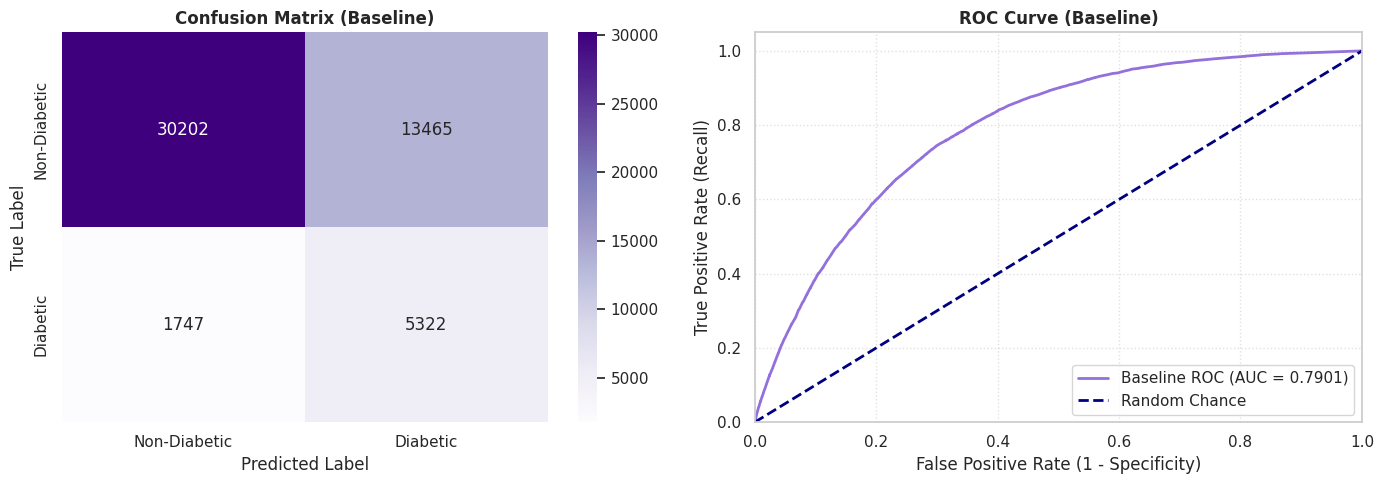

In [9]:
# Calculate probabilities for the baseline model to generate the ROC curve
y_pred_proba_base = rf_baseline.predict_proba(X_test)[:, 1]

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Baseline Confusion Matrix
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[0].set_title('Confusion Matrix (Baseline)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot 2: Baseline ROC Curve
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_proba_base)
roc_auc_base = roc_auc_score(y_test, y_pred_proba_base)

axes[1].plot(fpr_base, tpr_base, color='mediumpurple', lw=2, label=f'Baseline ROC (AUC = {roc_auc_base:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve (Baseline)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Hyperparameter Optimization

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the grid of hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Setup GridSearchCV strictly on X_train to prevent data leakage
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_

print("\nBest Hyperparameters Found:")
for key, value in grid_search.best_params_.items():
    print(f" - {key}: {value}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Hyperparameters Found:
 - max_depth: 10
 - min_samples_leaf: 2
 - min_samples_split: 5
 - n_estimators: 200


Feature Importance

/tmp/ipykernel_609/3428848602.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='mako')


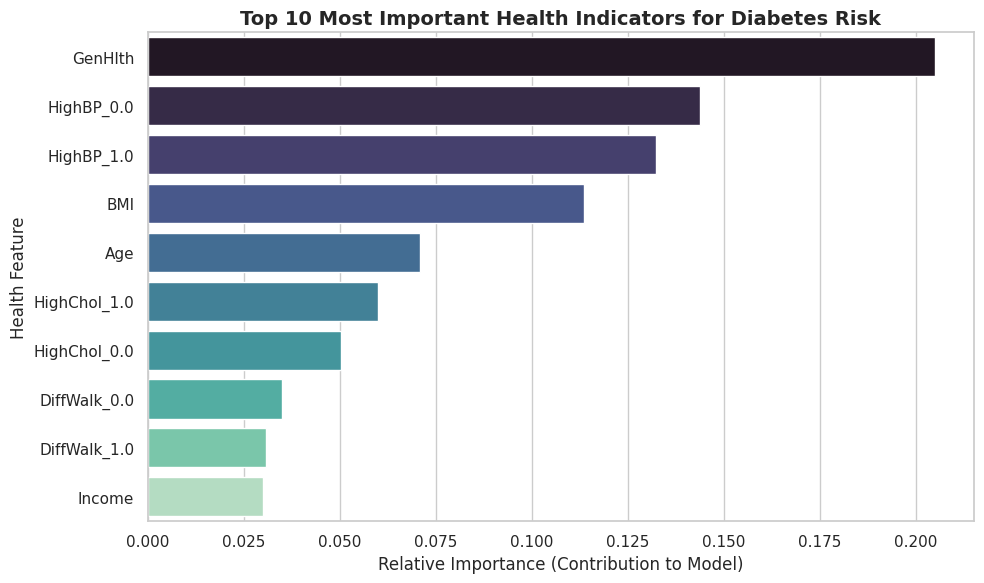

In [12]:
# Extract feature importances
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='mako')
plt.title('Top 10 Most Important Health Indicators for Diabetes Risk', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Contribution to Model)')
plt.ylabel('Health Feature')
plt.tight_layout()
plt.show()

Tuned Evaluation

In [13]:
# Generate predictions using the Tuned Model
y_train_pred = best_rf_model.predict(X_train)
y_train_proba = best_rf_model.predict_proba(X_train)[:, 1]

y_test_pred = best_rf_model.predict(X_test)
y_test_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Build comparison DataFrame
metrics_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Train Set (Balanced)": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_proba)
    ],
    "Test Set (Real-World)": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba)
    ]
}).round(4)

print("TUNED RANDOM FOREST: TRAIN VS TEST METRICS")
print("-" * 55)
print(metrics_comparison.to_string(index=False))

TUNED RANDOM FOREST: TRAIN VS TEST METRICS
-------------------------------------------------------
   Metric  Train Set (Balanced)  Test Set (Real-World)
 Accuracy                0.7659                 0.7157
Precision                0.7463                 0.3006
   Recall                0.8057                 0.7838
 F1-Score                0.7749                 0.4345
  ROC-AUC                0.8472                 0.8183


Model Visualizations

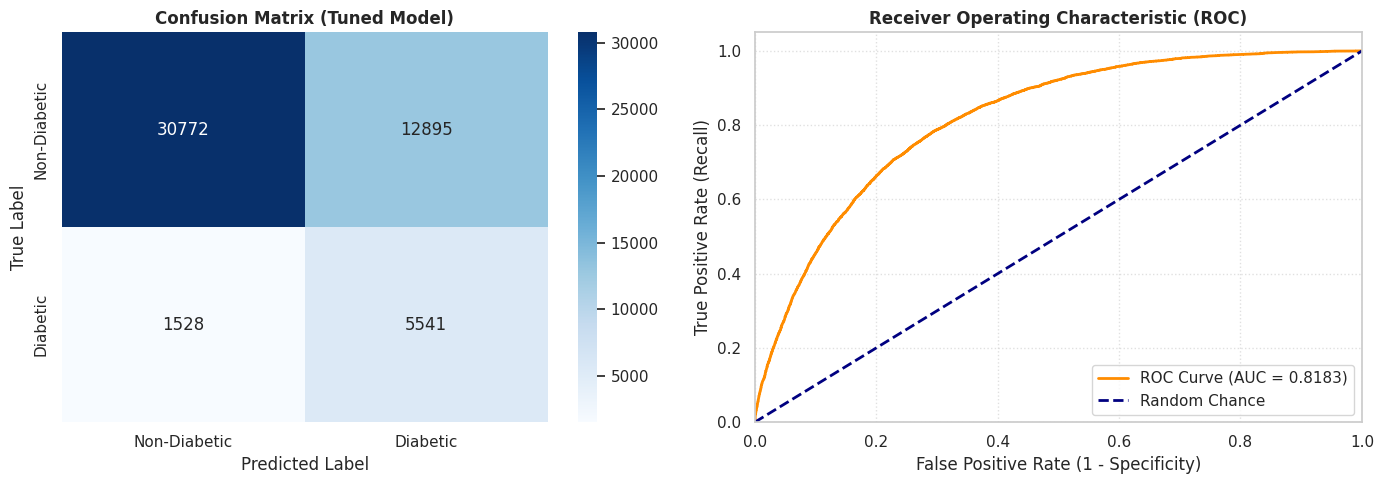

In [14]:
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[0].set_title('Confusion Matrix (Tuned Model)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 1. StandardScaler values used in preprocessing (fit on the training split).
#    Recovered from the raw -> scaled rows printed in drist_preprocessing.ipynb
#    (they reproduce those printed values to 6 decimals).
#    scaled = (raw - mean) / std
# ---------------------------------------------------------------------------
SCALER = {
    #            mean                 std
    'BMI':      (28.37796063467312,  6.598278052452251),
    'GenHlth':  (2.511835877603278,  1.0683753497000252),
    'MentHlth': (3.189796255943657,  7.417596070849912),
    'PhysHlth': (4.2508192635048685, 8.725625329210573),
    'Age':      (8.032826669695387,  3.0513800841713543),
    'Income':   (6.0508315832570085, 2.072655476231459),
}
NUM_FEATURES = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Income']

# One-hot encoded features (same order as the OneHotEncoder in preprocessing)
CAT_FEATURES = {
    'HighBP': [0, 1], 'HighChol': [0, 1], 'Smoker': [0, 1], 'Stroke': [0, 1],
    'HeartDiseaseorAttack': [0, 1], 'PhysActivity': [0, 1],
    'HvyAlcoholConsump': [0, 1], 'DiffWalk': [0, 1],
    'Education': [1, 2, 3, 4, 5, 6],
}
FEATURE_COLUMNS = NUM_FEATURES + [
    f"{c}_{float(v)}" for c, vals in CAT_FEATURES.items() for v in vals
]  # 6 + 22 = 28 columns, exactly like X_train


# ---------------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------------
def age_years_to_category(years):
    """BRFSS 'Age' is a 13-level category, not years (1 = 18-24 ... 13 = 80+)."""
    if years < 18:
        raise ValueError("The dataset only contains adults (18+).")
    if years >= 80:
        return 13
    if years < 25:
        return 1
    return int((years - 25) // 5) + 2   # 25-29 -> 2, 30-34 -> 3, ... 75-79 -> 12


def ask(prompt, valid=None, lo=None, hi=None, cast=float):
    """Keep asking until the answer is valid."""
    while True:
        try:
            val = cast(input(prompt).strip())
            if valid is not None and val not in valid:
                raise ValueError
            if lo is not None and not (lo <= val <= hi):
                raise ValueError
            return val
        except ValueError:
            print("   Invalid value, please try again.")


def preprocess(raw):
    """raw dict (original units) -> 1-row DataFrame, scaled + one-hot, 28 columns."""
    row = {f: (raw[f] - SCALER[f][0]) / SCALER[f][1] for f in NUM_FEATURES}
    for col, values in CAT_FEATURES.items():
        for v in values:
            row[f"{col}_{float(v)}"] = 1.0 if raw[col] == v else 0.0
    return pd.DataFrame([row], columns=FEATURE_COLUMNS)


# ---------------------------------------------------------------------------
# 3. Collect user input (original, un-scaled values)
# ---------------------------------------------------------------------------
yn = [0, 1]
print("Enter patient details (answer 1 = Yes, 0 = No for yes/no questions)\n")
raw = {}
age_years = ask("Age in years (18+): ", lo=18, hi=120)
raw['Age'] = age_years_to_category(age_years)
raw['BMI'] = ask("BMI (e.g. 27.5): ", lo=10, hi=100)
raw['GenHlth'] = ask("General health (1=Excellent, 2=Very good, 3=Good, 4=Fair, 5=Poor): ", valid=[1, 2, 3, 4, 5], cast=int)
raw['MentHlth'] = ask("Days of poor mental health in last 30 days (0-30): ", lo=0, hi=30)
raw['PhysHlth'] = ask("Days of poor physical health in last 30 days (0-30): ", lo=0, hi=30)
raw['Income'] = ask("Income level (1 = <$10k ... 8 = $75k+): ", valid=list(range(1, 9)), cast=int)
raw['Education'] = ask("Education (1=None/Kindergarten, 2=Elementary, 3=Some high school, "
                       "4=High school grad, 5=Some college, 6=College grad): ", valid=list(range(1, 7)), cast=int)
raw['HighBP'] = ask("High blood pressure? (1/0): ", valid=yn, cast=int)
raw['HighChol'] = ask("High cholesterol? (1/0): ", valid=yn, cast=int)
raw['Smoker'] = ask("Smoked 100+ cigarettes in lifetime? (1/0): ", valid=yn, cast=int)
raw['Stroke'] = ask("Ever had a stroke? (1/0): ", valid=yn, cast=int)
raw['HeartDiseaseorAttack'] = ask("Heart disease or heart attack? (1/0): ", valid=yn, cast=int)
raw['PhysActivity'] = ask("Physical activity in last 30 days? (1/0): ", valid=yn, cast=int)
raw['HvyAlcoholConsump'] = ask("Heavy alcohol consumption? (1/0): ", valid=yn, cast=int)
raw['DiffWalk'] = ask("Serious difficulty walking/climbing stairs? (1/0): ", valid=yn, cast=int)

# ---------------------------------------------------------------------------
# 4. Scale + encode, then predict with the trained model
# ---------------------------------------------------------------------------
patient = preprocess(raw)

# Sanity check: same columns/order as the training data
assert list(patient.columns) == list(X_train.columns), "Column mismatch with X_train!"

prediction = best_rf_model.predict(patient)[0]
probability = best_rf_model.predict_proba(patient)[0][1]
risk_label = "High Risk (Diabetes)" if prediction == 1 else "Low Risk (Non-Diabetic)"

print("\n" + "=" * 60)
print("        CUSTOM PATIENT DIABETES RISK ASSESSMENT")
print("=" * 60)
print(f"Prediction Result   : {risk_label}")
print(f"Diabetes Risk Score : {probability:.2%}")
print("=" * 60)

Enter patient details (answer 1 = Yes, 0 = No for yes/no questions)

Age in years (18+): 20
BMI (e.g. 27.5): 30
General health (1=Excellent, 2=Very good, 3=Good, 4=Fair, 5=Poor): 4
Days of poor mental health in last 30 days (0-30): 15
Days of poor physical health in last 30 days (0-30): 15
Income level (1 = <$10k ... 8 = $75k+): 4
Education (1=None/Kindergarten, 2=Elementary, 3=Some high school, 4=High school grad, 5=Some college, 6=College grad): 3
High blood pressure? (1/0): 1
High cholesterol? (1/0): 1
Smoked 100+ cigarettes in lifetime? (1/0): 1
Ever had a stroke? (1/0): 0
Heart disease or heart attack? (1/0): 0
Physical activity in last 30 days? (1/0): 0
Heavy alcohol consumption? (1/0): 1
Serious difficulty walking/climbing stairs? (1/0): 0

        CUSTOM PATIENT DIABETES RISK ASSESSMENT
Prediction Result   : Low Risk (Non-Diabetic)
Diabetes Risk Score : 47.59%


Threshold Tuning

Optimal Probability Threshold Identified: 0.61



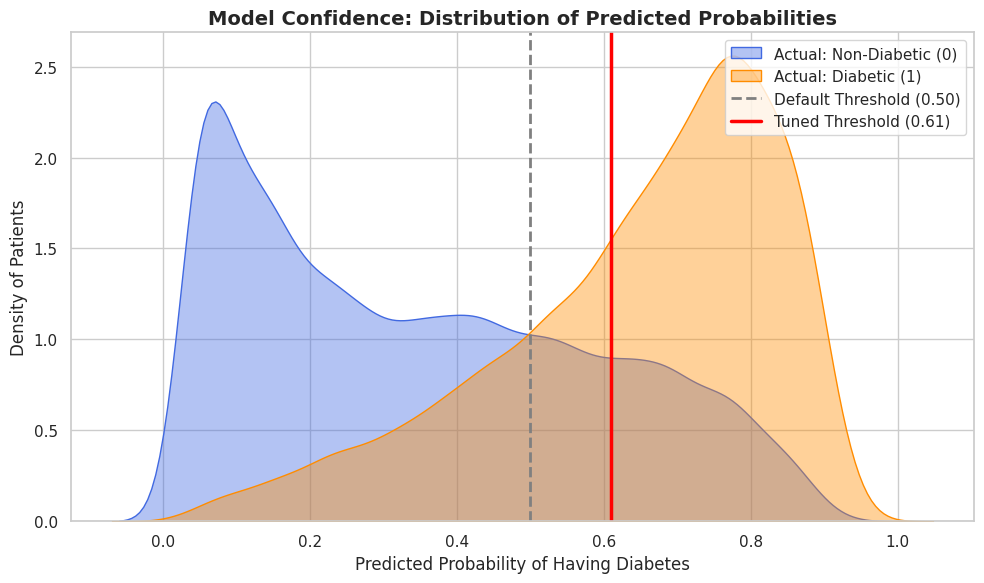


THRESHOLD COMPARISON (Hold-Out Set)
     Threshold  Accuracy  Precision  Recall  F1-score
Default (0.50)    0.7119     0.2958  0.7733    0.4279
  Tuned (0.61)    0.7863     0.3520  0.6355    0.4531


In [16]:
# Split test set securely
X_val, X_hold, y_val, y_hold = train_test_split(
    X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)

p_val  = best_rf_model.predict_proba(X_val)[:, 1]
p_hold = best_rf_model.predict_proba(X_hold)[:, 1]

MIN_RECALL = 0.65
best_t, best_acc = 0.50, -1

for t in np.round(np.arange(0.30, 0.91, 0.01), 2):
    pred = (p_val >= t).astype(int)
    if recall_score(y_val, pred) >= MIN_RECALL:
        acc = accuracy_score(y_val, pred)
        if acc > best_acc:
            best_t, best_acc = t, acc

print(f"Optimal Probability Threshold Identified: {best_t:.2f}\n")

# Plot the distribution of predicted probabilities
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test_proba[y_test == 0], label='Actual: Non-Diabetic (0)', fill=True, color='royalblue', alpha=0.4)
sns.kdeplot(y_test_proba[y_test == 1], label='Actual: Diabetic (1)', fill=True, color='darkorange', alpha=0.4)

plt.axvline(x=0.50, color='gray', linestyle='--', lw=2, label='Default Threshold (0.50)')
plt.axvline(x=best_t, color='red', linestyle='-', lw=2.5, label=f'Tuned Threshold ({best_t:.2f})')
plt.title('Model Confidence: Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of Having Diabetes')
plt.ylabel('Density of Patients')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print Table Comparison
print("\nTHRESHOLD COMPARISON (Hold-Out Set)")
rows = []
for name, t in [("Default (0.50)", 0.50), (f"Tuned ({best_t:.2f})", best_t)]:
    pred = (p_hold >= t).astype(int)
    rows.append({"Threshold": name, "Accuracy": round(accuracy_score(y_hold, pred), 4),
                 "Precision": round(precision_score(y_hold, pred), 4),
                 "Recall": round(recall_score(y_hold, pred), 4),
                 "F1-score": round(f1_score(y_hold, pred), 4)})
print(pd.DataFrame(rows).to_string(index=False))

Final Export

In [20]:
import joblib
from google.colab import files
# 1. Select the tuned model
model_to_save = best_rf_model
# 2. Save the file in Colab's environment
file_name = 'Random Forest Model.pkl'
joblib.dump(model_to_save, file_name)
# 3. desktop/downloads folder
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>